In [1]:
#tests of the method
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.stats as st
import scipy.special as sp
import scipy.signal as sig
import matplotlib.pyplot as plt

import noisefinder as nf
%matplotlib ipympl

NameError: name 'legendopt' is not defined

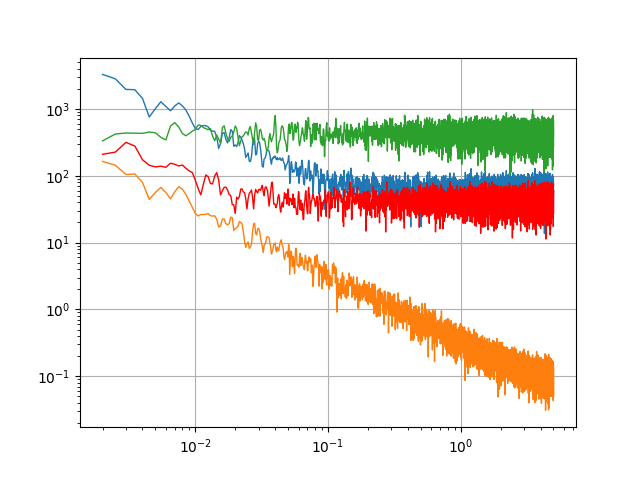

In [3]:
# just generate some data. make them correlated so that we test the entire method.
datres = np.cumsum(st.norm.rvs(size=50000))+100*st.norm.rvs(size=50000)
datB = 0.5*np.cumsum(st.norm.rvs(size=50000))
datC = 1000*st.norm.rvs(size=50000)
datA = datres+19*datB+0.10*datC

datres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
datB_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
datC_true = lambda f: 1000*np.sqrt(2/10)*f**0
datA_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [datA,datB,datC]

#calculate welch for comparison
PSDfres,PSDvres = sig.welch(datres,fs=10,window='blackmanharris',nperseg=20000)
PSDfA,PSDvA = sig.welch(datA,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = sig.welch(datB,fs=10,window='blackmanharris',nperseg=20000)
PSDfC,PSDvC = sig.welch(datC,fs=10,window='blackmanharris',nperseg=20000)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='datA')
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1,label='datB')
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1,label='datC')
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='residual')
ax.grid()
ax.legend()
ax.set_title('Generated data')
plt.show()

In [ ]:
#calculate with LPF method, for instance
meas_LPFmethod = nf.CPSD_LPFmethod(ts=meas,fs=10,Tmax=2000,fmax=1,verbose=True)

#extract parameters
meas_LPFmethod.cohere
meas_LPFmethod.CPSD
meas_LPFmethod.PSD
meas_LPFmethod.freqs
meas_LPFmethod.Ls
meas_LPFmethod.matp
meas_LPFmethod.navs
meas_LPFmethod.win
meas_LPFmethod.winscheme

In [ ]:
#extract quantiles
meas_LPFmethod_PSDq = meas_LPFmethod.PSDquantiles_eval(cval=0.68)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1)
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1)
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1)

tsidx = 0
ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:])-np.sqrt(meas_LPFmethod_PSDq[tsidx,0,:]),np.sqrt(meas_LPFmethod_PSDq[tsidx,2,:])-np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.')
tsidx = 1
ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:])-np.sqrt(meas_LPFmethod_PSDq[tsidx,0,:]),np.sqrt(meas_LPFmethod_PSDq[tsidx,2,:])-np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.')
tsidx = 2
ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:])-np.sqrt(meas_LPFmethod_PSDq[tsidx,0,:]),np.sqrt(meas_LPFmethod_PSDq[tsidx,2,:])-np.sqrt(meas_LPFmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.')
ax.grid()
ax.set_title('PSD LPF method')
plt.show()

In [ ]:
#same goes for MSC between two ts and R2

meas_LPFmethod_MSCq_AB = meas_LPFmethod.MSCquantiles_eval(idx1=0,idx2=1,cval=0.68)
meas_LPFmethod_MSCq_AC = meas_LPFmethod.MSCquantiles_eval(idx1=0,idx2=2,cval=0.68)
meas_LPFmethod_MSCq_BC = meas_LPFmethod.MSCquantiles_eval(idx1=1,idx2=2,cval=0.68)
meas_LPFmethod_R2q = meas_LPFmethod.R2quantiles_eval(cval=0.68)
meas_LPFmethod_R2q95 = meas_LPFmethod.R2quantiles_eval(cval=0.95)


MSCABtrue = lambda f: (19*datB_true(f)/datA_true(f))**2
MSCACtrue = lambda f: (0.1*datC_true(f)/datA_true(f))**2
MSCBCtrue = lambda f: 0*f
R2true = lambda f: 1-(datres_true(f)/datA_true(f))**2
faxis=np.logspace(-3,1,1000)

fig,ax=plt.subplots(2,1,figsize=(8,7),sharex=True)
ax[0].errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_MSCq_AB[:,1],
            yerr = [meas_LPFmethod_MSCq_AB[:,1]-meas_LPFmethod_MSCq_AB[:,0],meas_LPFmethod_MSCq_AB[:,2]-meas_LPFmethod_MSCq_AB[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C0',fmt='.',label='MSC AB')
ax[0].plot(faxis,MSCABtrue(faxis),c='C0')
ax[0].errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_MSCq_AC[:,1],
            yerr = [meas_LPFmethod_MSCq_AC[:,1]-meas_LPFmethod_MSCq_AC[:,0],meas_LPFmethod_MSCq_AC[:,2]-meas_LPFmethod_MSCq_AC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C1',fmt='.',label='MSC AC')
ax[0].plot(faxis,MSCACtrue(faxis),c='C1')
ax[0].errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_MSCq_BC[:,1],
            yerr = [meas_LPFmethod_MSCq_BC[:,1]-meas_LPFmethod_MSCq_BC[:,0],meas_LPFmethod_MSCq_BC[:,2]-meas_LPFmethod_MSCq_BC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C2',fmt='.',label='MSC BC')
ax[0].plot(faxis,MSCBCtrue(faxis),c='C2')
ax[0].grid()
ax[0].set_xscale('log')
ax[0].set_ylim([0,1])
ax[0].set_title('MSC LPF method')
ax[0].legend()


ax[1].errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_R2q[:,1],
            yerr = [meas_LPFmethod_R2q[:,1]-meas_LPFmethod_R2q[:,0],meas_LPFmethod_R2q[:,2]-meas_LPFmethod_R2q[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',label='R2 68%')
ax[1].errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_R2q95[:,1],
            yerr = [meas_LPFmethod_R2q95[:,1]-meas_LPFmethod_R2q95[:,0],meas_LPFmethod_R2q95[:,2]-meas_LPFmethod_R2q95[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',alpha=0.5,label='R2 95%')
ax[1].plot(faxis,R2true(faxis),c='k')
ax[1].grid()
ax[1].set_xscale('log')
ax[1].set_ylim([0,1])
ax[1].set_title('R2 LPF method')
ax[1].legend()
plt.show()

In [ ]:
# what if I want to make a nice violinplot? For instance, of MSC A-C.

#first, get the posteriors
MSCaxis = np.linspace(1e-6,1-1e-6,500)
MSCpost_AC = meas_LPFmethod.MSCposterior_eval(MSCaxis,idx1=0,idx2=2)
MSCpost_AB = meas_LPFmethod.MSCposterior_eval(MSCaxis,idx1=0,idx2=1)

#PDFs are normalized, but we need them with fixed amplitude.
MSCpost_AC = [rho2post/np.max(rho2post) for rho2post in MSCpost_AC]
MSCpost_AB = [rho2post/np.max(rho2post) for rho2post in MSCpost_AB]

def violinplotter(f,PDFs,ax,violinwidth=0.15,**kwargs):
    # Plot each PDF as a mirrored violin
    for i in range(len(f)):
        logx = np.log10(f[i])
        vw = f[i+1]/f[i]-1 if i==0 else f[i]/f[i-1]-1 if i==len(f)-1 else min(f[i]/f[i-1]-1,f[i+1]/f[i]-1)
        scaled_pdf = PDFs[i] * vw * violinwidth  # Width in log-space
        left = logx - scaled_pdf
        right = logx + scaled_pdf

        # Back to linear space for plotting
        left_lin = 10**left
        right_lin = 10**right
        # Draw symmetrical violin around frequency
        ax.fill_betweenx(MSCaxis, left_lin, right_lin,**kwargs)
    return

fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_MSCq_AC[:,1],
            yerr = [meas_LPFmethod_MSCq_AC[:,1]-meas_LPFmethod_MSCq_AC[:,0],meas_LPFmethod_MSCq_AC[:,2]-meas_LPFmethod_MSCq_AC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C1',fmt='.',label='MSC AC')
ax.plot(faxis,MSCACtrue(faxis),c='C1')
violinplotter(f=meas_LPFmethod.freqs,PDFs=MSCpost_AC,ax=ax,
              facecolor='darkorange', alpha=0.3, edgecolor=None, linewidth=0.5)

ax.errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_MSCq_AB[:,1],
            yerr = [meas_LPFmethod_MSCq_AB[:,1]-meas_LPFmethod_MSCq_AB[:,0],meas_LPFmethod_MSCq_AB[:,2]-meas_LPFmethod_MSCq_AB[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C0',fmt='.',label='MSC AB')
ax.plot(faxis,MSCABtrue(faxis),c='C0')
violinplotter(f=meas_LPFmethod.freqs,PDFs=MSCpost_AB,ax=ax, 
              facecolor='C0', alpha=0.3, edgecolor=None, linewidth=0.5)

ax.grid()
ax.set_xscale('log')
ax.set_ylim([0,1])
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
#R2 violin plot
R2post = meas_LPFmethod.R2posterior_eval(MSCaxis)
#PDFs are normalized, but we need them with fixed amplitude.
R2post = [R2/np.max(R2) for R2 in R2post]

fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_R2q[:,1],
            yerr = [meas_LPFmethod_R2q[:,1]-meas_LPFmethod_R2q[:,0],meas_LPFmethod_R2q[:,2]-meas_LPFmethod_R2q[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',label='R2 68%')

violinplotter(f=meas_LPFmethod.freqs,PDFs=R2post,ax=ax, 
              facecolor='k', alpha=0.3, edgecolor=None, linewidth=0.5)

ax.plot(faxis,R2true(faxis),c='k')
ax.grid()
ax.set_xscale('log')
ax.set_ylim([0,1])
ax.set_title('R2 violin')
ax.legend()
plt.show()